In [4]:
# Import dataset from kaggle
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import pandas as pd

# Load the dataset
df = pd.read_csv('Loan_approval_data_2025.csv')

# Defines the split for train/test 80/20
def evaluate_model(X, y, test_size=0.2, random_state=42):
    # Train logistic regression model
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)

    # Logistic Regression
    model = LogisticRegression(solver='liblinear', random_state=random_state)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Print results clearly
    print(f"ACCURACY: {accuracy_score(y_test, y_pred):.2%}")

    #Confusion Matrix
    print("CONFUSION MATRIX:")
    cm_df = pd.DataFrame(
        confusion_matrix(y_test, y_pred),
        index=['Actual No (0)', 'Actual Yes (1)'],
        columns=['Predicted No (0)', 'Predicted Yes (1)']
    )
    print(cm_df)

    #Classifications
    print("CLASSIFICATION REPORT:")
    print(classification_report(y_test, y_pred))

    return model

# Define Target
y = df['loan_status']

# Model 1: Without Categorical Variables
print("--- Model 1: Without Categorical Variables ---")
# Dropping strings and customer ID for baseline
# Restructured compared to previous baseline - same output
columns_to_drop_baseline = ['customer_id', 'occupation_status', 'product_type', 'loan_intent', 'loan_status']
X_no_cat = df.drop(columns=columns_to_drop_baseline)

model_no_cat = evaluate_model(X_no_cat, y)

# Model 2: With Categorical Variables
print("\n--- Model 2: With Categorical Variables ---")
# Keep categorical variables but encode them (One-Hot Encoding)
# Also still drop customer_id as it's just an identifier
X_with_cat = df.drop(columns=['customer_id', 'loan_status'])
X_with_cat = pd.get_dummies(X_with_cat, drop_first=True)

model_with_cat = evaluate_model(X_with_cat, y)

--- Model 1: Without Categorical Variables ---
ACCURACY: 73.56%
CONFUSION MATRIX:
                Predicted No (0)  Predicted Yes (1)
Actual No (0)               3020               1489
Actual Yes (1)              1155               4336
CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0       0.72      0.67      0.70      4509
           1       0.74      0.79      0.77      5491

    accuracy                           0.74     10000
   macro avg       0.73      0.73      0.73     10000
weighted avg       0.73      0.74      0.73     10000


--- Model 2: With Categorical Variables ---
ACCURACY: 73.89%
CONFUSION MATRIX:
                Predicted No (0)  Predicted Yes (1)
Actual No (0)               3039               1470
Actual Yes (1)              1141               4350
CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0       0.73      0.67      0.70      4509
           1       0.75      0.79      0.77 


--- Model 3: With Scaling ---
ACCURACY: 87.08%
CONFUSION MATRIX:
                Predicted No (0)  Predicted Yes (1)
Actual No (0)               3841                668
Actual Yes (1)               624               4867
CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0       0.86      0.85      0.86      4509
           1       0.88      0.89      0.88      5491

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



 Total features in model: 24

--- Full Feature Importance Table ---


,Feature,Coefficient,Abs_Coefficient
7,defaults_on_file,-2.829194,2.829194
17,product_type_Line of Credit,-1.891257,1.891257
11,interest_rate,-1.837964,1.837964
18,product_type_Personal Loan,-1.685465,1.685465
12,debt_to_income_ratio,-1.332501,1.332501
20,loan_intent_Education,1.012564,1.012564
3,credit_score,0.814359,0.814359
8,delinquencies_last_2yrs,-0.780034,0.780034
4,credit_history_years,0.743920,0.743920
23,loan_intent_Personal,0.742267,0.742267


/tmp/ipykernel_4399/4154412228.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Abs_Coefficient', y='Feature', data=coeffs, palette='viridis')


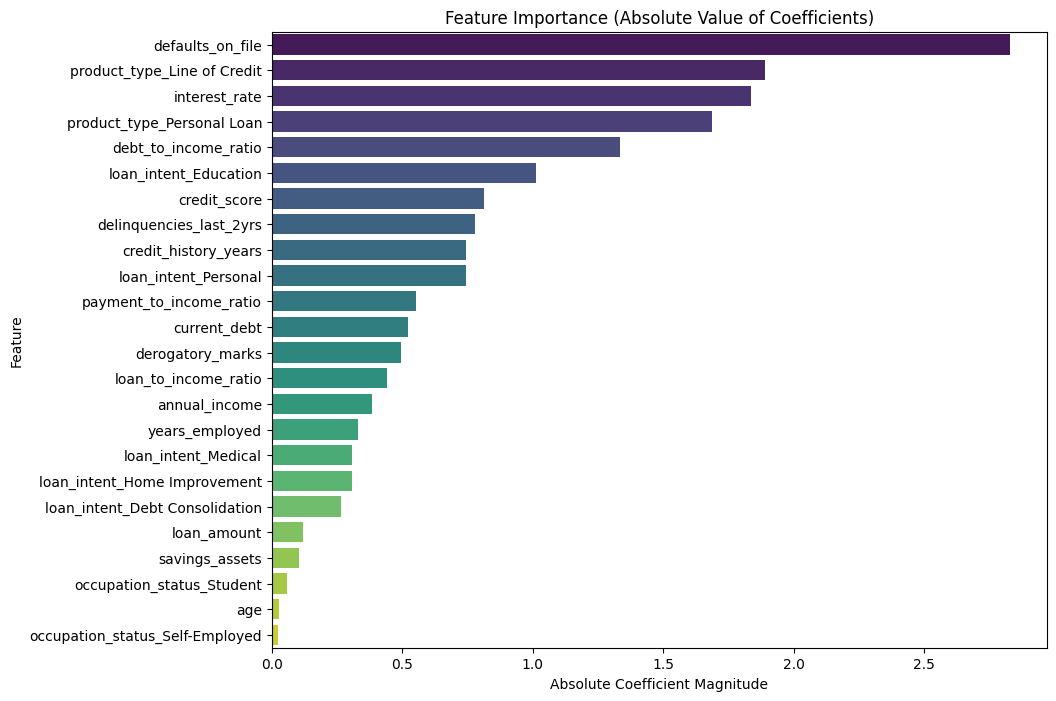

In [5]:
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Data Scaling
print("\n--- Model 3: With Scaling ---")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_with_cat)

# Re-run evaluation with scaled data
model_scaled = evaluate_model(X_scaled, y)

# Feature Importance
# Get coefficients from the scaled model
coeffs = pd.DataFrame({
    'Feature': X_with_cat.columns,
    'Coefficient': model_scaled.coef_[0]
})

#  Sort by absolute value of coefficient to see most important features
coeffs['Abs_Coefficient'] = coeffs['Coefficient'].abs()
coeffs = coeffs.sort_values(by='Abs_Coefficient', ascending=False)

# Display the full list of features and their importance values
print(f"\n\n Total features in model: {len(coeffs)}")

# Display the dataframe sorted by importance
print("\n--- Full Feature Importance Table ---")
display(coeffs)

# Plot
plt.figure(figsize=(10, 8))
sns.barplot(x='Abs_Coefficient', y='Feature', data=coeffs, palette='viridis')
plt.title("Feature Importance (Absolute Value of Coefficients)")
plt.xlabel("Absolute Coefficient Magnitude")
plt.show()

In [6]:
from sklearn.ensemble import RandomForestClassifier

# Model 4: Random Forest
print("\n--- Model 4: Random Forest ---")

# Split data (using the categorical dataset)
X_train, X_test, y_train, y_test = train_test_split(X_with_cat, y, test_size=0.2, random_state=42)

# Initialize and Train
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Predict
y_pred = rf_model.predict(X_test)

# Eval
print(f"ACCURACY: {accuracy_score(y_test, y_pred):.2%}")

print("CONFUSION MATRIX:")
print(pd.DataFrame(confusion_matrix(y_test, y_pred),
                   index=['Actual No', 'Actual Yes'],
                   columns=['Pred No', 'Pred Yes']))

print("CLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred))


--- Model 4: Random Forest ---
ACCURACY: 91.41%
CONFUSION MATRIX:
            Pred No  Pred Yes
Actual No      4061       448
Actual Yes      411      5080
CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0       0.91      0.90      0.90      4509
           1       0.92      0.93      0.92      5491

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



In [7]:
from sklearn.ensemble import GradientBoostingClassifier

# Model 5: Gradient Boosting
print("\n--- Model 5: Gradient Boosting ---")

# Initialize and Train
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)

# Predict
y_pred = gb_model.predict(X_test)

# Eval
print(f"ACCURACY: {accuracy_score(y_test, y_pred):.2%}")

print("CONFUSION MATRIX:")
print(pd.DataFrame(confusion_matrix(y_test, y_pred),
                   index=['Actual No', 'Actual Yes'],
                   columns=['Pred No', 'Pred Yes']))

print("CLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred))


--- Model 5: Gradient Boosting ---
ACCURACY: 92.04%
CONFUSION MATRIX:
            Pred No  Pred Yes
Actual No      4042       467
Actual Yes      329      5162
CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0       0.92      0.90      0.91      4509
           1       0.92      0.94      0.93      5491

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000




--- Model 4: Random Forest Feature Importance ---


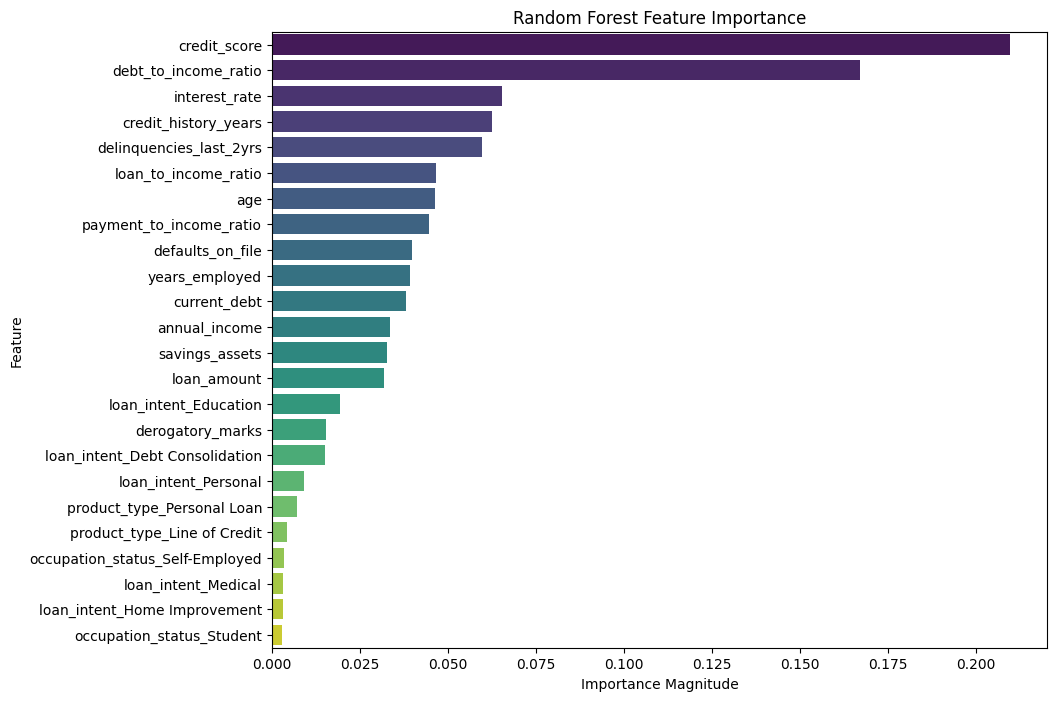


--- Model 5: Gradient Boosting Feature Importance ---


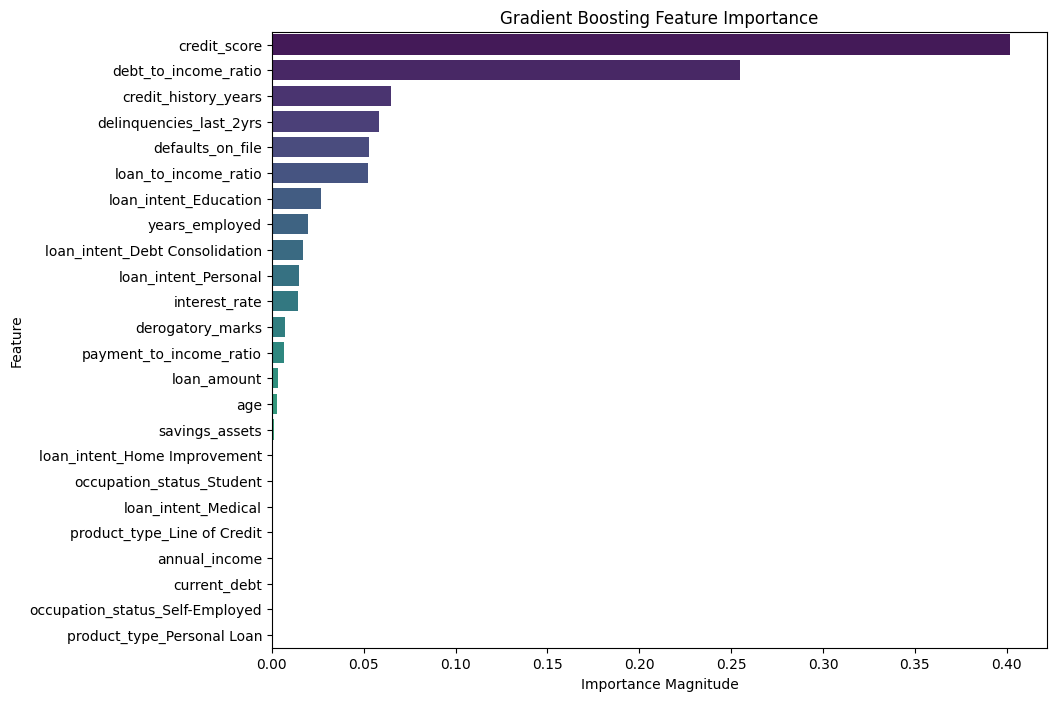

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Model 4: Random Forest Feature Importance
print("\n--- Model 4: Random Forest Feature Importance ---")
rf_importances = pd.DataFrame({
    'Feature': X_with_cat.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=rf_importances, hue='Feature', palette='viridis', legend=False)
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Magnitude")
plt.show()

# Model 5: Gradient Boosting Feature Importance
print("\n--- Model 5: Gradient Boosting Feature Importance ---")
gb_importances = pd.DataFrame({
    'Feature': X_with_cat.columns,
    'Importance': gb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=gb_importances, hue='Feature', palette='viridis', legend=False)
plt.title("Gradient Boosting Feature Importance")
plt.xlabel("Importance Magnitude")
plt.show()


--- Model Comparison: ROC Curve ---


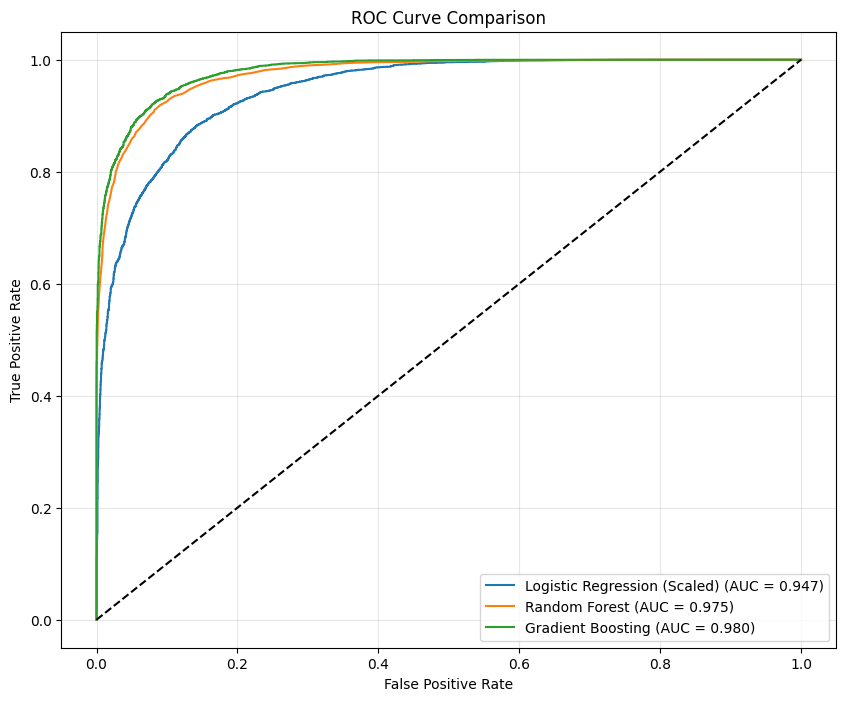

In [9]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Model Comparison: ROC Curve
print("\n--- Model Comparison: ROC Curve ---")
plt.figure(figsize=(10, 8))

# Split X_scaled using the same random_state as before so rows align with y_test
_, X_test_scaled, _, _ = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# List of models to compare
models = [
    ('Logistic Regression (Scaled)', model_scaled, X_test_scaled), # Uses matching scaled test data
    ('Random Forest', rf_model, X_test), # RF uses unscaled X_test
    ('Gradient Boosting', gb_model, X_test) # GB uses unscaled X_test
]

for name, model, X_val in models:
    # Predict probabilities
    y_prob = model.predict_proba(X_val)[:, 1]

    # Calculate ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)

    # Plot
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

# Plot formatting
plt.plot([0, 1], [0, 1], 'k--') # Random guess line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

In [10]:
from sklearn.ensemble import GradientBoostingClassifier

# Model 6: Feature Engineering Comparison
print("\n--- Model 6: Feature Engineering & Comparison ---")

# Create a copy of the categorical dataset
X_fe = X_with_cat.copy()

# Feature 1: Credit Stability Ratio (Credit Score / Years Employed)
X_fe['credit_stability_ratio'] = X_fe['credit_score'] / (X_fe['years_employed'] + 1e-6)

# Feature 2: Income Stability (Annual Income / Years Employed)
X_fe['income_stability'] = X_fe['annual_income'] / (X_fe['years_employed'] + 1e-6)

# Feature 3: Loan Burden (Loan Amount / Credit Score)
X_fe['loan_burden'] = X_fe['loan_amount'] / (X_fe['credit_score'] + 1e-6)

# Feature 4: Composite Risk (Loan Amount / (Income * Credit Score))
X_fe['composite_risk'] = X_fe['loan_amount'] / ((X_fe['annual_income'] * X_fe['credit_score']) + 1e-6)

# Display examples of the new features
print("\nExamples of New Feature-Engineered Columns")
display(X_fe[['credit_stability_ratio', 'income_stability', 'loan_burden', 'composite_risk']].head())

# For simplicity Scaled version for LogReg and unscaled for Trees.

# 1. Logistic Regression (Scaled)
scaler_fe = StandardScaler()
X_fe_scaled = scaler_fe.fit_transform(X_fe)
print("\n[Model 6a] Logistic Regression (Feature Engineered):")
model_fe_lr = evaluate_model(X_fe_scaled, y)

# 2. Tree Models
X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(X_fe, y, test_size=0.2, random_state=42)

# Random Forest
print("\n[Model 6b] Random Forest (Feature Engineered):")
rf_fe = RandomForestClassifier(random_state=42)
rf_fe.fit(X_train_fe, y_train_fe)
y_pred_rf = rf_fe.predict(X_test_fe)
print(f"ACCURACY: {accuracy_score(y_test_fe, y_pred_rf):.2%}")

# Gradient Boosting
print("\n[Model 6c] Gradient Boosting (Feature Engineered):")
gb_fe = GradientBoostingClassifier(random_state=42)
gb_fe.fit(X_train_fe, y_train_fe)
y_pred_gb = gb_fe.predict(X_test_fe)
print(f"ACCURACY: {accuracy_score(y_test_fe, y_pred_gb):.2%}")


--- Model 6: Feature Engineering & Comparison ---

Examples of New Feature-Engineered Columns


,credit_stability_ratio,income_stability,loan_burden,composite_risk
0,40.232556,1487.151076,0.867052,0.000034
1,85.890399,5902.327959,85.007974,0.001973
2,626.363067,18945.437322,3.047895,0.000146
3,1383.997232,58293.883412,4.190751,0.000144
4,50.399996,5092.559593,158.095238,0.002484



[Model 6a] Logistic Regression (Feature Engineered):
ACCURACY: 87.29%
CONFUSION MATRIX:
                Predicted No (0)  Predicted Yes (1)
Actual No (0)               3832                677
Actual Yes (1)               594               4897
CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0       0.87      0.85      0.86      4509
           1       0.88      0.89      0.89      5491

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000


[Model 6b] Random Forest (Feature Engineered):
ACCURACY: 91.04%

[Model 6c] Gradient Boosting (Feature Engineered):
ACCURACY: 91.99%
